# Phase 4: Model Evaluation and Comparison

This phase evaluates the performance of all trained models using metrics such as R², RMSE, and MAE. Visualizations are generated to compare model performance and analyze prediction accuracy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/Data-Driven-Energy-Project')

Mounted at /content/drive


In [3]:
results_df = pd.read_csv("outputs/tables/model_results.csv")
results_df

,Model,R2,RMSE,MAE
0,Decision Tree,0.996304,0.620644,0.424805
1,Decision Tree,0.996304,0.620644,0.424805
2,Random Forest,0.997689,0.490798,0.354648
3,Gradient Boosting,0.997455,0.515084,0.386159
4,SVR,0.923539,2.823060,1.888638
5,KNN,0.949173,2.301693,1.452662
6,Neural Network,0.991471,0.942863,0.681785
7,Neural Network,0.991471,0.942863,0.681785
8,Random Forest,0.997689,0.490798,0.354648
9,Gradient Boosting,0.997455,0.515084,0.386159


R² COMPARISON

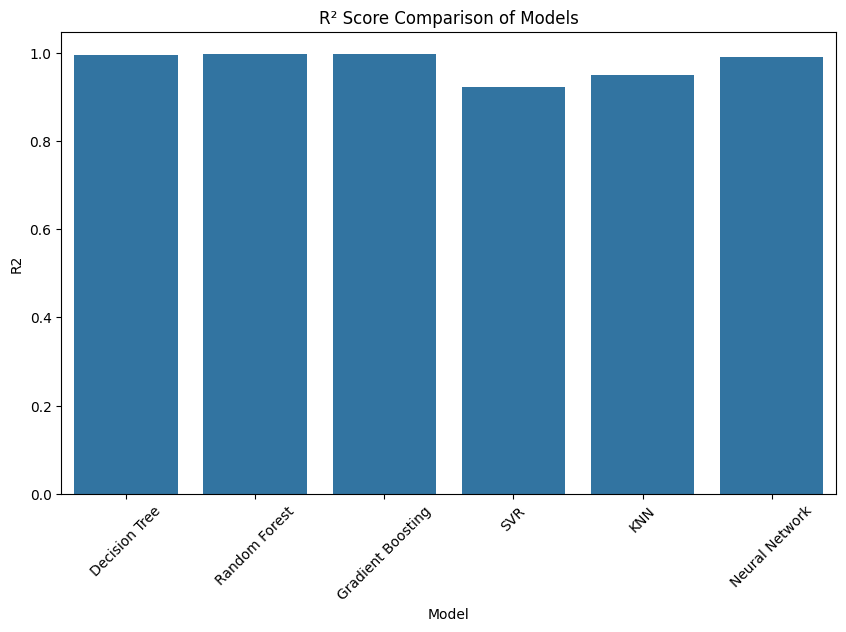

In [4]:
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="R2", data=results_df)
plt.title("R² Score Comparison of Models")
plt.xticks(rotation=45)

os.makedirs("outputs/graphs", exist_ok=True)
plt.savefig("outputs/graphs/06_r2_comparison.png")

plt.show()

RMSE COMPARISON

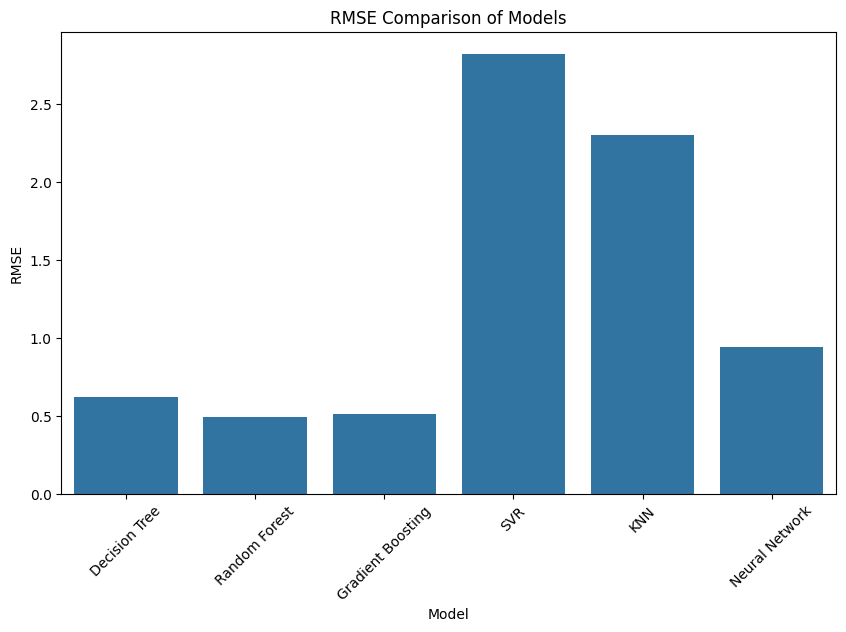

In [5]:
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="RMSE", data=results_df)
plt.title("RMSE Comparison of Models")
plt.xticks(rotation=45)

plt.savefig("outputs/graphs/07_rmse_comparison.png")

plt.show()

MAE COMPARISON

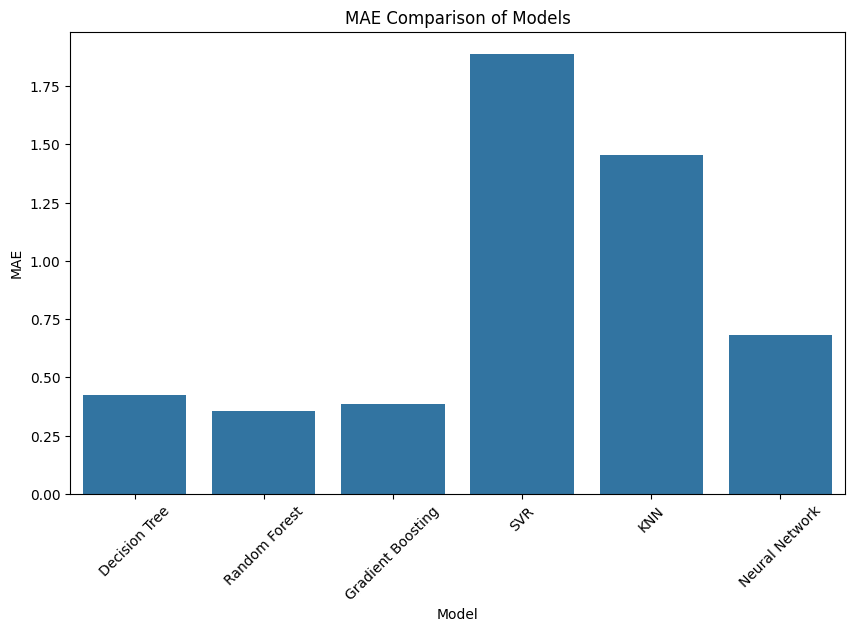

In [6]:
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="MAE", data=results_df)
plt.title("MAE Comparison of Models")
plt.xticks(rotation=45)

plt.savefig("outputs/graphs/08_mae_comparison.png")

plt.show()

ACTUAL vs PREDICTED

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/energy_efficiency.csv", encoding='latin1')


df.columns = [
    "Relative_Compactness",
    "Surface_Area",
    "Wall_Area",
    "Roof_Area",
    "Height",
    "Orientation",
    "Glazing_Area",
    "Glazing_Distribution",
    "Heating_Load",
    "Cooling_Load"
]
df = df.dropna()

X = df.drop(["Heating_Load", "Cooling_Load"], axis=1)
y = df["Heating_Load"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

ACTUAL vs PREDICTED PLOT

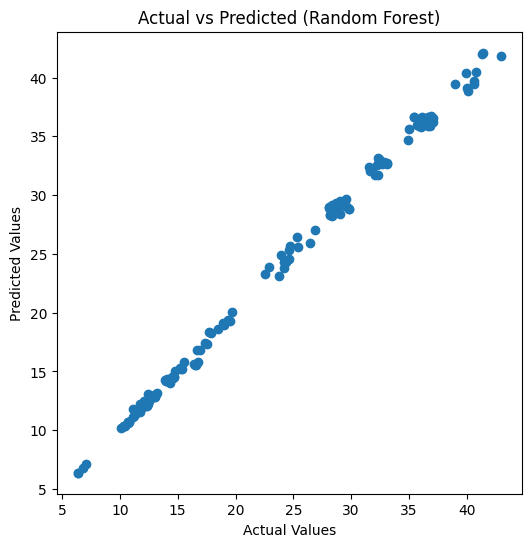

In [10]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")

plt.savefig("outputs/graphs/09_actual_vs_predicted.png")

plt.show()

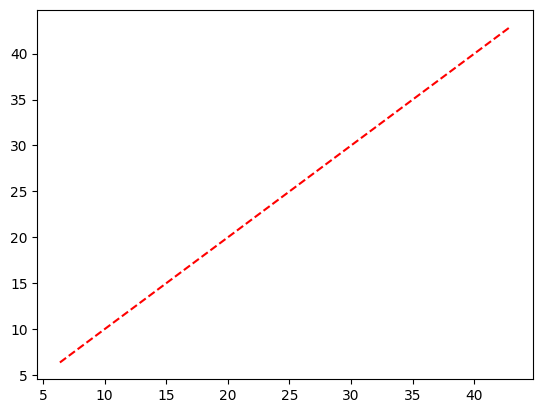

In [11]:
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')